# Домашнее задание 2. Классификация изображений.

В этом задании потребуется обучить классификатор изображений. Будем работать с датасетом по классификации emoji из тг. Можете посмотреть самостоятельно на картинки, которые в есть датасете. В нём 100 классов и около 100 картинок на каждый класс. Классы пронумерованы, кодом смайлика к которому относятся элементы класса. Скачать датасет можно вот [тут](https://disk.yandex.ru/d/elNF0DS94o2GVA).

Структура датасета -- есть директории train/ и val/, в которых лежат обучающие и валидационные данные. В train/ и val/ лежат директориии, соответствующие классам изображений, в которых лежат, собственно, сами изображения.

__Задание__. Необходимо выполнить два задания

1) Добейтесь accuracy **на валидации не менее 0.4**. В этом задании **запрещено** пользоваться предобученными моделями и ресайзом картинок. 5 баллов

2) Добейтесь accuracy **на валидации не менее 0.8**. В этом задании делать ресайз и использовать претрейн можно. 5 баллов

Напишите краткий отчёт о проделанных экспериментах. Что сработало и что не сработало? Почему вы решили, сделать так, а не иначе? Обязательно указывайте ссылки на чужой код, если вы его используете. Обязательно ссылайтесь на статьи / блогпосты / вопросы на stackoverflow / видосы от ютуберов-машинлернеров / курсы / подсказки от Дяди Васи и прочие дополнительные материалы, если вы их используете.

Ваш код обязательно должен проходить все `assert`'ы ниже.

__Использовать внешние данные для обучения строго запрещено в обоих заданиях. Также запрещено обучаться на валидационной выборке__.


__Критерии оценки__: Оценка вычисляется по простой формуле: `min(5, 5 * Ваша accuracy / 0.4)` для первого задания и `min(5, 5 * (Ваша accuracy - 0.4) / 0.4)` для второго. Оценка считается как сумма за оба задания и потом округляется до десятых по арифметическим правилам.


__Советы и указания__:
 - Наверняка вам потребуется много гуглить о классификации и о том, как заставить её работать. Это нормально, все гуглят. Но не забывайте, что нужно быть готовым за скатанный код отвечать :)
 - Используйте аугментации. Для этого пользуйтесь модулем `torchvision.transforms` или библиотекой [albumentations](https://github.com/albumentations-team/albumentations)
 - Можно обучать с нуля или файнтюнить (в зависимости от задания) модели из `torchvision`.
 - Рекомендуем написать вам сначала класс-датасет (или воспользоваться классом `ImageFolder`), который возвращает картинки и соответствующие им классы, а затем функции для трейна по шаблонам ниже. Однако делать это мы не заставляем. Если вам так неудобно, то можете писать код в удобном стиле. Однако учтите, что чрезмерное изменение нижеперечисленных шаблонов увеличит количество вопросов к вашему коду :)
 - Валидируйте. Трекайте ошибки как можно раньше, чтобы не тратить время впустую.
 - Чтобы быстро отладить код, пробуйте обучаться на маленькой части датасета (скажем, 5-10 картинок просто чтобы убедиться что код запускается). Когда вы поняли, что смогли всё отдебажить, переходите обучению по всему датасету
 - На каждый запуск делайте ровно одно изменение в модели/аугментации/оптимайзере, чтобы понять, что и как влияет на результат.
 - Фиксируйте random seed.
 - Начинайте с простых моделей и постепенно переходите к сложным. Обучение лёгких моделей экономит много времени.
 - Ставьте расписание на learning rate. Уменьшайте его, когда лосс на валидации перестаёт убывать.
 - Советуем использовать GPU. Если у вас его нет, используйте google colab. Если вам неудобно его использовать на постоянной основе, напишите и отладьте весь код локально на CPU, а затем запустите уже написанный ноутбук в колабе.

Good luck & have fun! :)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install wandb esda > /dev/null 2>&1 # hide output
!pip3 install pytorch_lightning torchmetrics esda > /dev/null 2>&1 # hide output

**✨ Внимание ✨**


В этом домашнем задании предлагается использовать библиотеку `pytorch_lightning`. Доступ к ее [документации](https://lightning.ai/docs/pytorch/stable/) заблокирован с территории РФ. Вы можете:

1. Получить к ней доступ с помощью VPN.

2. Собрать документацию самостоятельно. Для этого склонируйте [github-репозиторий](https://github.com/Lightning-AI/lightning/tree/master), запустите в нем терминал (на windows – git bash) и выполните команды:

```shell
git submodule update --init --recursive
make docs
```
После этого откройте появившийся файл `docs/build/html/index.html`. Для работы команд в вашем окружении должен быть `pip`. Полная инструкция [по ссылке](https://github.com/Lightning-AI/lightning/tree/master/docs).

3. Гуглить `<error message> pytorch lightning` или `<how to do this> pytorch lightning`. Stack overflow на территории РФ все еще доступен 😉

4. Не пользоваться `pytorch_lightning` и написать цикл обучения модели самостоятельно. Например, по аналогии с функцией `fit` из [семинара 4](https://github.com/hse-ds/iad-deep-learning/blob/master/2023/seminars/04.%20Optim%20%26%20Lightning/04_Optim%26Lightning_solution.ipynb).

In [3]:
# # Возможно ниже будет не очень работать WandbLogger с первого разу, перезапустите kernel тетрадки
# import wandb

# wandb.login()

In [4]:
import math
import os
import random
import sys

import matplotlib.pyplot as plt
import numpy as np
import pytorch_lightning as pl
import torch
import torchvision
import torchvision.transforms as transforms
from PIL import Image
from pytorch_lightning.loggers import WandbLogger
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader
from torchmetrics.functional import accuracy as calc_accuracy
from torchvision.datasets import ImageFolder
from tqdm import tqdm
import torchvision.transforms as T
from IPython.display import clear_output
import torchvision.models as models
import albumentations as A
from albumentations.pytorch import ToTensorV2
import ipywidgets as widgets
from torchvision.models import efficientnet_b0

In [5]:
def seed_everything(seed):
    # Фискирует максимум сидов.
    # Это понадобится, чтобы сравнение оптимизаторов было корректным
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True


seed_everything(123456)

## Задание 0

### Что поможет сделать на 10 из 10 (одно задание - 5 баллов)

1. Использовать все возможные методы оптимизации и эксперемнтировать с ними.
2. Подбор learning rate. Пример из прошлого семинара как это делать: [Как найти lr](https://pytorch-lightning.readthedocs.io/en/1.4.5/advanced/lr_finder.html)

```
  trainer = pl.Trainer(accelerator="gpu", max_epochs=2, auto_lr_find=True)

  trainer.tune(module, train_dataloader, eval_dataloader)

  trainer.fit(module, train_dataloader, eval_dataloader))
```



3. Аугментация данных. [Документация (полезная)](https://pytorch.org/vision/main/transforms.html), а также [библиотека albumentation](https://towardsdatascience.com/getting-started-with-albumentation-winning-deep-learning-image-augmentation-technique-in-pytorch-47aaba0ee3f8)
4. Подбор архитектуры модели.
5. Можно написать свою модель руками в классе YourNet, а можно импортировать не предобученную сетку известной архитектуры из модуля torchvision.models. Один из способов как можно сделать:

  * `torchvision.models.resnet18(pretrained=False, num_classes=200).to(device)`
  * Документация по возможным моделям и как их можно брать: [Документация (полезная)](https://pytorch.org/vision/stable/models.html)
6. Правильно нормализовывать данные при создании, пример [тык, но тут и в целом гайд от и до](https://www.pluralsight.com/guides/image-classification-with-pytorch)
7. Model Checkpointing. Сохраняйте свой прогресс (модели), чтобы когда что-то пойдет не так вы сможете начать с этого места или просто воспроизвести свои результаты модели, которые обучали.
 * Пример как можно с wandb тут: [Сохраняем лучшие модели в wandb](https://docs.wandb.ai/guides/integrations/lightning)
 * По простому можно так: [Сохраняем модели в pytorch дока](https://pytorch.org/tutorials/beginner/saving_loading_models.html)

### Подготовка данных

In [6]:
# Unzip the data
!unzip -qo "/content/drive/My Drive/Deep_Learning/train.zip"
!unzip -qo "/content/drive/My Drive/Deep_Learning/val.zip"

Inspired by https://albumentations.ai/docs/examples/example/

In [7]:
train_transforms = A.Compose(
    [
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=360, p=0.5),
        A.RGBShift(r_shift_limit=15, g_shift_limit=15, b_shift_limit=15, p=0.4),
        A.RandomBrightnessContrast(p=0.4),
        A.MultiplicativeNoise(multiplier=[0.5, 2], per_channel=True, p=0.1),
        A.HueSaturationValue(hue_shift_limit=0.2, sat_shift_limit=0.2, val_shift_limit=0.2, p=0.4),
        A.RandomBrightnessContrast(brightness_limit=(-0.1, 0.1), contrast_limit=(-0.1, 0.1), p=0.4),
        A.Normalize(
            mean=(0.544268535904948, 0.5078093085177952, 0.4505041277235243),
            std=(0.260139962956694, 0.2563979034887267, 0.25556574095234724)
        ),
        ToTensorV2()
    ]
)

test_transforms = A.Compose(
    [
        A.Normalize(
            mean=(0.544268535904948, 0.5078093085177952, 0.4505041277235243),
            std=(0.260139962956694, 0.2563979034887267, 0.25556574095234724)
        ),
        ToTensorV2()
    ]
)

val_transform = A.Compose(
    [
        A.Normalize(
            mean=(0.544268535904948, 0.5078093085177952, 0.4505041277235243),
            std=(0.260139962956694, 0.2563979034887267, 0.25556574095234724)
        ),
        ToTensorV2()
    ]
)

# Create a wrapper class to use albumentations with ImageFolder
class AlbumentationsTransform:
    def __init__(self, transform):
        self.transform = transform

    def __call__(self, image):
        # Convert PIL image to numpy array
        image = np.array(image)
        # Apply the albumentations transform; it expects a keyword argument 'image'
        augmented = self.transform(image=image)
        # Return the transformed image from the dictionary
        return augmented["image"]

# Wrap transforms
wrapped_train_transform = AlbumentationsTransform(train_transforms)
wrapped_val_transform = AlbumentationsTransform(val_transform)
wrapped_test_transform = AlbumentationsTransform(test_transforms)

# Use the wrapped transforms in datasets

train_dataset = torchvision.datasets.ImageFolder('./train', transform=wrapped_train_transform)
val_dataset = torchvision.datasets.ImageFolder('./val', transform=wrapped_val_transform)

# Create DataLoaders

train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
val_dataloader = torch.utils.data.DataLoader(val_dataset, batch_size=64, shuffle=True, num_workers=2)

/usr/local/lib/python3.11/dist-packages/albumentations/core/validation.py:87: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [8]:
# Just very simple sanity checks
assert isinstance(train_dataset[0], tuple)
assert len(train_dataset[0]) == 2
assert isinstance(train_dataset[1][1], int)
print("tests passed")

tests passed


### Посмотрим на картиночки

Image[5] shape: torch.Size([3, 128, 128])
Image[19] shape: torch.Size([3, 128, 128])


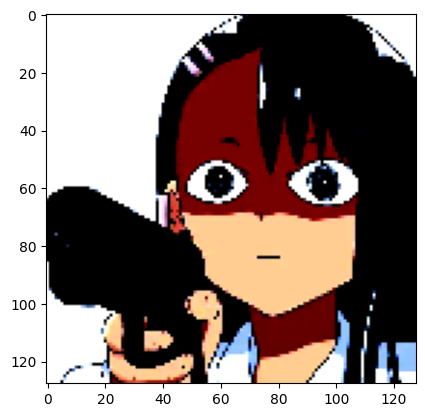

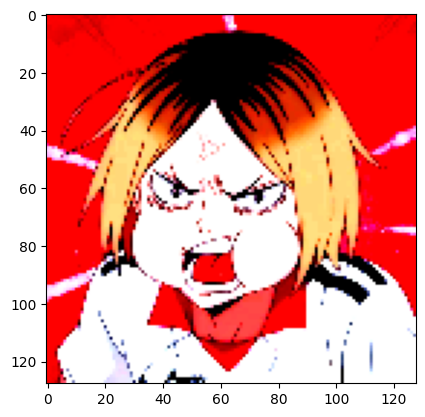

In [9]:
for batch in val_dataloader:
    images, class_nums = batch
    # Print the shapes of specific images in the batch
    print("Image[5] shape:", images[5].shape)
    print("Image[19] shape:", images[19].shape)

    plt.imshow(images[5].permute(1, 2, 0))
    plt.show()
    plt.imshow(images[19].permute(1, 2, 0))
    plt.show()
    break

## Задание 1.

5 баллов
Добейтесь accuracy на валидации не менее 0.4. В этом задании запрещено пользоваться предобученными моделями и ресайзом картинок.


Для того чтобы выбить скор (считается ниже) на 2.5/5 балла (то есть половину за задание) достаточно соблюдать пару простых жизненных правил:
1. Аугментация (без нее сложно очень будет)
2. Оптимайзеры можно (и нужно) использовать друг с другом. Однако когда что-то проверяете, то не меняйте несколько параметров сразу - собьете логику экспериментов
3. Не используйте полносвязные модели или самые первые сверточные, используйте более современные архитектуры (что на лекциях встречались)
4. Посмотреть ноутбуки прошедших семинаров и создайте из них что-то общее. Семинарских тетрадок хватит сверх

### Модель (или просто импортируйте не предобученную)

Import resnet, not pretrained (from section 4), also define the plotting fucntion.

In [10]:
# Architectures

from torchvision.models import resnet18


# Plotting functions
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='darkgrid')

def plot_stats(train_loss: list[float],
               valid_loss: list[float],
               train_accuracy: list[float],
               valid_accuracy: list[float],
               title: str):
    # We update only the plot area
    with plot_out:
        plot_out.clear_output(wait=True)
        n = min(len(train_loss), len(valid_loss), len(train_accuracy), len(valid_accuracy))
        if n == 0:
            return
        epochs = range(1, n + 1)

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

        # Plot Loss curves
        ax1.plot(epochs, train_loss[:n], marker='o', label='Train Loss')
        ax1.plot(epochs, valid_loss[:n], marker='o', label='Validation Loss')
        ax1.set_title(title + ' Loss')
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Loss')
        ax1.legend()
        ax1.grid(True)

        # Plot Accuracy curves
        ax2.plot(epochs, train_accuracy[:n], marker='o', label='Train Accuracy')
        ax2.plot(epochs, valid_accuracy[:n], marker='o', label='Validation Accuracy')
        ax2.set_title(title + ' Accuracy')
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('Accuracy')
        ax2.legend()
        ax2.grid(True)

        plt.tight_layout()
        plt.show()

def log_epoch(epoch: int, train_loss: float, train_acc: float, val_loss: float, val_acc: float):
    # Append the epoch info to the log output widget
    with log_out:
        print(f"Epoch {epoch}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

### Тренировочный класс lightning

In [11]:
class EmojiClassifier(pl.LightningModule):
    def __init__(self, model, learning_rate=1e-3):
        super().__init__()
        self.model = model  # e.g., non-pretrained ResNet18 with num_classes=100
        self.learning_rate = learning_rate

        # Lists to store metrics for custom plotting
        self.train_losses = []
        self.train_accuracies = []
        self.val_losses = []
        self.val_accuracies = []

        # Internal counters for get_accuracy
        self._batch_correct = 0
        self._batch_total = 0

    def forward(self, x, labels=None):
        """
        If labels are provided, compute the loss and update internal accuracy counters.
        Otherwise, simply return model outputs.
        """
        outputs = self.model(x)
        if labels is not None:
            loss = F.cross_entropy(outputs, labels)
            preds = outputs.argmax(dim=1)
            self._batch_correct = (preds == labels).sum().item()
            self._batch_total = labels.size(0)
            return loss
        return outputs

    def get_accuracy(self, reset=False):
        """
        Returns the accuracy of the last forward pass (when labels were provided).
        If reset=True, it resets the internal counters.
        """
        if self._batch_total > 0:
            acc = self._batch_correct / self._batch_total
        else:
            acc = 0.0
        if reset:
            self._batch_correct = 0
            self._batch_total = 0
        return acc

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        acc = calc_accuracy(logits, y, task="multiclass", num_classes=100)
        self.log('train_loss', loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log('train_acc', acc, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def on_train_epoch_end(self):
        metrics = self.trainer.callback_metrics
        train_loss = metrics.get("train_loss")
        train_acc = metrics.get("train_acc")
        if train_loss is not None and train_acc is not None:
            self.train_losses.append(train_loss.item())
            self.train_accuracies.append(train_acc.item())

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        acc = calc_accuracy(logits, y, task="multiclass", num_classes=100)
        self.log('val_loss', loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log('val_acc', acc, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def on_validation_epoch_end(self):
        # Skip for epoch 0
        if self.current_epoch == 0:
            return

        metrics = self.trainer.callback_metrics
        val_loss = metrics.get("val_loss")
        val_acc = metrics.get("val_acc")
        if val_loss is not None and val_acc is not None:
            self.val_losses.append(val_loss.item())
            self.val_accuracies.append(val_acc.item())
            plot_stats(self.train_losses, self.val_losses,
                      self.train_accuracies, self.val_accuracies,
                      "Epoch Metrics")

            if self.train_losses and self.train_accuracies:
                latest_train_loss = self.train_losses[-1]
                latest_train_acc = self.train_accuracies[-1]
            else:
                latest_train_loss = float('nan')
                latest_train_acc = float('nan')

            # Print both training and validation metrics for this epoch
            print(f"Epoch {self.current_epoch}: "
                  f"Train Loss: {latest_train_loss:.4f}, Train Acc: {latest_train_acc:.4f} | "
                  f"Val Loss: {val_loss.item():.4f}, Val Acc: {val_acc.item():.4f}")

            # Custom early stopping logic:
            # Check if there have been at least 5 validation epochs so far
            if len(self.val_accuracies) >= 5:
                # Get the last 5 validation accuracies
                recent_acc = self.val_accuracies[-5:]
                # If the maximum improvement among these is less than or equal to 0.001, then stop training
                if max(recent_acc) - min(recent_acc) <= 0.001:
                    print("Early stopping triggered: Validation accuracy did not improve by more than 0.001 in the last 5 epochs.")
                    self.trainer.should_stop = True

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.model.parameters(), lr=self.learning_rate, weight_decay=1e-8, betas=(0.9, 0.999))
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3)
        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "monitor": "val_loss",
                "frequency": 1
            }
        }

### Model training

#### Take the subset of the data for training

In [12]:
import random
from torch.utils.data import Subset

# set a seed for reproducibility
# random.seed(42)

part = 1
# For training dataset:
num_train_samples = len(train_dataset)
train_indices = list(range(num_train_samples))
random.shuffle(train_indices)
train_subset_size = int(part * num_train_samples)
train_subset_indices = train_indices[:train_subset_size]
train_subset = Subset(train_dataset, train_subset_indices)

# For validation dataset:
num_val_samples = len(val_dataset)
val_indices = list(range(num_val_samples))
random.shuffle(val_indices)
val_subset_size = int(part * num_val_samples)
val_subset_indices = val_indices[:val_subset_size]
val_subset = Subset(val_dataset, val_subset_indices)

# Now, create DataLoaders for the subsets
train_dataloader = torch.utils.data.DataLoader(train_subset, batch_size=256, shuffle=True, num_workers=2) # 256
val_dataloader = torch.utils.data.DataLoader(val_subset, batch_size=256, shuffle=True, num_workers=2)

Now the training:

In [13]:
# Create separate output widgets for plots and logs.
plot_out = widgets.Output()
log_out = widgets.Output()

# Display these outputs
display(log_out)
display(plot_out)

Output()

Output()

In [14]:
# Instantiate a non-pretrained ResNet18 with 100 classes
# model = resnet18(pretrained=False, num_classes=100) # 24.7 - aproximate accuracy after around 30 epochs
# model = models.efficientnet_b0(pretrained=False, num_classes=100) # 24
model = models.densenet121(pretrained=False, num_classes=100) #26
# model = models.convnext_tiny(pretrained=False, num_classes=100) # < 20

# Create the Lightning module (named EmojiClassifier)
module = EmojiClassifier(model=model, learning_rate=1e-3)

# Set up the Trainer with updated parameters for Lightning v2
trainer = pl.Trainer(max_epochs=50, accelerator="gpu", devices=1)

# Fit model using train and validation dataloaders
trainer.fit(module, train_dataloader, val_dataloader)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
INFO:pytorch_lightning.utilities.rank_zero:You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:You are using a CUDA device

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:476: Your `val_dataloader`'s sampler has shuffling enabled, it is strongly recommended that you turn shuffling off for val/test dataloaders.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Epoch 48: Train Loss: 2.1633, Train Acc: 0.4181 | Val Loss: 3.1178, Val Acc: 0.2812


Validation: |          | 0/? [00:00<?, ?it/s]

Epoch 49: Train Loss: 2.1636, Train Acc: 0.4177 | Val Loss: 3.1252, Val Acc: 0.2768


INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=50` reached.


### Валидация результатов задания

In [15]:
def evaluate_task(model, test_dataloader, device="cuda:0"):
    model = model.to(device)
    model.eval()
    accuracy = 0.0
    for images, labels in tqdm(test_dataloader):
        images, labels = images.to(device), labels.to(device)
        with torch.no_grad():
            loss = model(images, labels)
            acc_batch = model.get_accuracy(reset=True)
        accuracy += acc_batch
    accuracy = accuracy / len(test_dataloader)
    return accuracy

In [16]:
model = module
accuracy = evaluate_task(model, val_dataloader)
print(f"Оценка за это задание составит {np.clip(5 * accuracy / 0.4, 0, 5):.2f} баллов")

100%|██████████| 10/10 [00:01<00:00,  5.42it/s]

Оценка за это задание составит 3.46 баллов


## Задание 2

5 баллов
Добейтесь accuracy на валидации не менее 0.8. В этом задании делать ресайз и использовать претрейн можно.

Для того чтобы выбить скор (считается ниже) на 2.5/5 балла (то есть половину за задание) достаточно соблюдать пару простых жизненных правил:
1. Аугментация (без нее сложно очень будет)
2. Оптимайзеры лучше используйте Adam c параметрами по умолчанию как стартовую точку.
3. Не используйте полносвязные модели или самые первые сверточные, используйте более современные архитектуры (что на лекциях встречались или можете пойти дальше).
4. Попробуйте сначала посмотреть качество исходной модели без дообучения, сохраните как baseline. Отсюда поймете какие слои нужно дообучать.
5. Посмотреть все ноутбуки прошедших семинаров и создайте из них что-то общее. Семинарских тетрадок хватит сверх

In [17]:
# Delete large variables as they're no longer needed
del module
del trainer
del train_dataloader
del val_dataloader

# Force garbage collection to free up memory
import gc
gc.collect()

# Clear GPU memory cache (if using CUDA)
torch.cuda.empty_cache()

In [18]:
# Training transformations: Upscale to 224x224 then apply other augmentations
train_transforms = A.Compose([
    # Resize the image from 128x128 to 224x224
    A.Resize(height=224, width=224),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=360, p=0.5),
    A.RGBShift(r_shift_limit=15, g_shift_limit=15, b_shift_limit=15, p=0.4),
    A.RandomBrightnessContrast(p=0.4),
    A.MultiplicativeNoise(multiplier=[0.5,2], per_channel=True, p=0.1),
    A.HueSaturationValue(hue_shift_limit=0.2, sat_shift_limit=0.2, val_shift_limit=0.2, p=0.4),
    A.RandomBrightnessContrast(brightness_limit=(-0.1, 0.1), contrast_limit=(-0.1, 0.1), p=0.4),
    A.Normalize(
        mean=(0.544268535904948, 0.5078093085177952, 0.4505041277235243),
        std=(0.260139962956694, 0.2563979034887267, 0.25556574095234724)
    ),
    ToTensorV2()
])

# Testing transformations: Also resize to 224x224
test_transforms = A.Compose([
    A.Resize(height=224, width=224),
    A.Normalize(
        mean=(0.544268535904948, 0.5078093085177952, 0.4505041277235243),
        std=(0.260139962956694, 0.2563979034887267, 0.25556574095234724)
    ),
    ToTensorV2()
])

# Wrap transforms
wrapped_train_transform = AlbumentationsTransform(train_transforms)
wrapped_val_transform = AlbumentationsTransform(val_transform)
wrapped_test_transform = AlbumentationsTransform(test_transforms)

# Use the wrapped transforms in datasets

train_dataset = torchvision.datasets.ImageFolder('./train', transform=wrapped_train_transform)
val_dataset = torchvision.datasets.ImageFolder('./val', transform=wrapped_val_transform)

# Create DataLoaders

train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=512, shuffle=True, num_workers=2)
val_dataloader = torch.utils.data.DataLoader(val_dataset, batch_size=512, shuffle=True, num_workers=2)

/usr/local/lib/python3.11/dist-packages/albumentations/core/validation.py:87: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


### Модель (или просто импортируйте предобученную)

### Тренировочный класс lightning

In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pytorch_lightning as pl
from torchmetrics.functional import accuracy as calc_accuracy

class EmojiClassifier_advanced(pl.LightningModule):
    def __init__(self, model, learning_rate=1e-3):
        super().__init__()
        self.model = model  # Pretrained model with custom classifier head already attached
        self.learning_rate = learning_rate

        # Freeze the backbone:
        # For models with 'features' (like DenseNet)
        if hasattr(self.model, "features"):
            for param in self.model.features.parameters():
                param.requires_grad = False
        else:
            # Assume ResNet-like: freeze all parameters except those in the final layer ('fc')
            for name, param in self.model.named_parameters():
                if "fc" not in name:
                    param.requires_grad = False

        # Lists to store metrics for custom plotting
        self.train_losses = []
        self.train_accuracies = []
        self.val_losses = []
        self.val_accuracies = []

        # Internal counters for get_accuracy (if used)
        self._batch_correct = 0
        self._batch_total = 0

        # Flag to ensure unfreezing happens only once
        self.unfreeze_done = False

    def forward(self, x, labels=None):
        outputs = self.model(x)
        if labels is not None:
            loss = F.cross_entropy(outputs, labels)
            preds = outputs.argmax(dim=1)
            self._batch_correct = (preds == labels).sum().item()
            self._batch_total = labels.size(0)
            return loss
        return outputs

    def get_accuracy(self, reset=False):
        if self._batch_total > 0:
            acc = self._batch_correct / self._batch_total
        else:
            acc = 0.0
        if reset:
            self._batch_correct = 0
            self._batch_total = 0
        return acc

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        acc = calc_accuracy(logits, y, task="multiclass", num_classes=100)
        self.log('train_loss', loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log('train_acc', acc, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def on_train_epoch_end(self):
        metrics = self.trainer.callback_metrics
        train_loss = metrics.get("train_loss")
        train_acc = metrics.get("train_acc")
        if train_loss is not None and train_acc is not None:
            self.train_losses.append(train_loss.item())
            self.train_accuracies.append(train_acc.item())

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        acc = calc_accuracy(logits, y, task="multiclass", num_classes=100)
        self.log('val_loss', loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log('val_acc', acc, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def on_validation_epoch_end(self):
        if self.current_epoch == 0:
            return

        metrics = self.trainer.callback_metrics
        val_loss = metrics.get("val_loss")
        val_acc = metrics.get("val_acc")
        if val_loss is not None and val_acc is not None:
            self.val_losses.append(val_loss.item())
            self.val_accuracies.append(val_acc.item())
            plot_stats(self.train_losses, self.val_losses,
                       self.train_accuracies, self.val_accuracies,
                       "Epoch Metrics")

            if self.train_losses and self.train_accuracies:
                latest_train_loss = self.train_losses[-1]
                latest_train_acc = self.train_accuracies[-1]
            else:
                latest_train_loss = float('nan')
                latest_train_acc = float('nan')

            print(f"Epoch {self.current_epoch}: "
                  f"Train Loss: {latest_train_loss:.4f}, Train Acc: {latest_train_acc:.4f} | "
                  f"Val Loss: {val_loss.item():.4f}, Val Acc: {val_acc.item():.4f}")

            # Custom early stopping: if the last 5 validation accuracies vary by <= 0.001, stop training.
            if len(self.val_accuracies) >= 5:
                recent_acc = self.val_accuracies[-5:]
                if max(recent_acc) - min(recent_acc) <= 0.001:
                    print("Early stopping triggered: Validation accuracy did not improve by more than 0.001 in the last 5 epochs.")
                    self.trainer.should_stop = True

    def on_epoch_start(self):
        # Gradually unfreeze layers at a chosen epoch (e.g., epoch 3)
        if self.current_epoch == 3 and not self.unfreeze_done:
            self.unfreeze_done = True
            print("Unfreezing part of the backbone for fine-tuning.")
            # For DenseNet-like models:
            if hasattr(self.model, "features"):
                for param in self.model.features.denseblock4.parameters():
                    param.requires_grad = True
                for param in self.model.features.norm5.parameters():
                    param.requires_grad = True
                optimizer = self.trainer.optimizers[0]
                optimizer.add_param_group({'params': self.model.features.denseblock4.parameters(), 'lr': self.learning_rate * 0.1})
                optimizer.add_param_group({'params': self.model.features.norm5.parameters(), 'lr': self.learning_rate * 0.1})
                print("DenseNet backbone updated with unfrozen parameters.")
            else:
                # For ResNet-like models, unfreeze the last block (e.g., layer4)
                for param in self.model.layer4.parameters():
                    param.requires_grad = True
                optimizer = self.trainer.optimizers[0]
                optimizer.add_param_group({'params': self.model.layer4.parameters(), 'lr': self.learning_rate * 0.1})
                print("ResNet backbone (layer4) updated with unfrozen parameters.")

    def configure_optimizers(self):
        # Set differential learning rates:
        # For DenseNet-like models, use model.features; for ResNet, use parameters not in fc.
        if hasattr(self.model, "features"):
            optimizer = torch.optim.AdamW([
                {"params": self.model.features.parameters(), "lr": self.learning_rate * 0.1},
                {"params": self.model.classifier.parameters(), "lr": self.learning_rate}
            ], weight_decay=1e-4, betas=(0.9, 0.999))
        else:
            optimizer = torch.optim.AdamW([
                {"params": [param for name, param in self.model.named_parameters() if "fc" not in name], "lr": self.learning_rate * 0.1},
                {"params": self.model.fc.parameters(), "lr": self.learning_rate}
            ], weight_decay=1e-4, betas=(0.9, 0.999))

        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=3, factor=0.5)
        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "monitor": "val_loss",
                "frequency": 1
            }
        }


#### Take the subset of the data for training

In [20]:
import random
from torch.utils.data import Subset

# random.seed(42)

part = 1
# For training dataset:
num_train_samples = len(train_dataset)
train_indices = list(range(num_train_samples))
random.shuffle(train_indices)
train_subset_size = int(part * num_train_samples)
train_subset_indices = train_indices[:train_subset_size]
train_subset = Subset(train_dataset, train_subset_indices)

# For validation dataset:
num_val_samples = len(val_dataset)
val_indices = list(range(num_val_samples))
random.shuffle(val_indices)
val_subset_size = int(part * num_val_samples)
val_subset_indices = val_indices[:val_subset_size]
val_subset = Subset(val_dataset, val_subset_indices)

# Now, create DataLoaders for the subsets
train_dataloader = torch.utils.data.DataLoader(train_subset, batch_size=256, shuffle=True, num_workers=2)
val_dataloader = torch.utils.data.DataLoader(val_subset, batch_size=256, shuffle=True, num_workers=2)

Define the layers which are trained on top of the pretrained model

In [21]:
# class CustomClassifier(nn.Module):
#     def __init__(self, in_features, num_classes=100):
#         super().__init__()
#         self.fc1 = nn.Linear(in_features, 512)
#         self.dropout = nn.Dropout(0.5)
#         self.fc2 = nn.Linear(512, num_classes)

#     def forward(self, x):
#         x = self.fc1(x)
#         x = F.relu(x)
#         x = self.dropout(x)
#         x = self.fc2(x)
#         return x

In [22]:
class CustomClassifier(nn.Module):
    def __init__(self, in_features, num_classes=100):
        super().__init__()
        self.fc1 = nn.Linear(in_features, num_classes)

    def forward(self, x):
        x = self.fc1(x)
        return x

Now the training:

In [23]:
# set up tracker
wandb_logger = WandbLogger(
    project="emoji_classification_densenet121",
    name="densenet121",
    log_model='all'
)

# Log hyperparameters
wandb_logger.log_hyperparams({
    "learning_rate": 1e-3,
    "batch_size": 128,
    "architecture": "densenet121 + CustomClassifier (linear layer)",
    "unfreeze_epoch": 3,
    "optimizer": "AdamW",
    "scheduler": "ReduceLROnPlateau"
})


wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: nickpupkin (nickpupkin-nes) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [24]:
# Create separate output widgets for plots and logs.
plot_out = widgets.Output()
log_out = widgets.Output()

# Display these outputs
display(log_out)
display(plot_out)

Output()

Output()

In [25]:
# Load the pretrained DenseNet121
model = models.densenet121(pretrained=True)
model.classifier = CustomClassifier(in_features=model.classifier.in_features, num_classes=100)

# Load the pretrained resnet18
# model = resnet18(pretrained=True)
# model.fc = CustomClassifier(in_features=model.fc.in_features, num_classes=100)

# Load the pretrained efficientnet_b0
# model = efficientnet_b0(pretrained=True)
# in_features = model.classifier[1].in_features
# model.classifier = CustomClassifier(in_features=in_features, num_classes=100)

# Instantiate a non-pretrained ResNet18 with 100 classes
# model = models.convnext_tiny(pretrained=False, num_classes=100)

# Create the Lightning module (named EmojiClassifier_advanced)
module = EmojiClassifier_advanced(model=model, learning_rate=1e-3)

# Set up the Trainer with updated parameters for Lightning v2
trainer = pl.Trainer(max_epochs=50, accelerator="gpu", devices=1)

# Fit model using train and validation dataloaders
trainer.fit(module, train_dataloader, val_dataloader)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth
100%|██████████| 30.8M/30.8M [00:00<00:00, 153MB/s]
INFO:pytorch_lightning.utilities.rank_zero:You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
INFO

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:476: Your `val_dataloader`'s sampler has shuffling enabled, it is strongly recommended that you turn shuffling off for val/test dataloaders.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Epoch 48: Train Loss: 2.9218, Train Acc: 0.2516 | Val Loss: 4.4348, Val Acc: 0.1220


Validation: |          | 0/? [00:00<?, ?it/s]

Epoch 49: Train Loss: 2.9203, Train Acc: 0.2554 | Val Loss: 4.4595, Val Acc: 0.1240


INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=50` reached.


### Валидация результатов задания

In [27]:
model = module
accuracy = evaluate_task(model, val_dataloader)
print(f"Оценка за это задание составит {np.clip(5 * (accuracy - 0.4)/ 0.4, 0, 5):.2f} баллов")

100%|██████████| 10/10 [00:01<00:00,  5.71it/s]

Оценка за это задание составит 0.00 баллов


# Important!

I KINDLY ASK TO TREAT MY MODEL IN THE FIRST TASK AS THE MODEL FOR THE SECOND TASK, AS IT HAS HIGHER ACCURACY THAN THE LAST ONE (FOR SOME REASON).

# Отчёт об экспериментах

текст писать тут (или ссылочку на wandb/любой трекер экспреиментов) для каждого задания, то есть не обязательно именно тут рисовать графики, если вы используете готовые трекеры/мониторинги ваших моделей.

I mainly played mainly with bathc size - decided to do 256 at the end. Also played with models - see the training process in the 1st task. Also tried different models for the 2nd task, but all the hypoparameters and architecture kept the same- not enough time. I also recorded one of the experiments here https://wandb.ai/nickpupkin/projects but not much- only recently got my head around that website.